# 05 — One variable at a time

Workflow step 5. Four model-axis experiments against the exp_0001 baseline, each
changing exactly one thing, plus the deliberate composition of the winners. The
content of this notebook is not the scores — it is **how to read them**: paired on
the frozen folds, against the fit-vs-val gap, against the resolution.

Every run cell is idempotent: the first execution trains (~1–10 min each), every
later execution reloads the logged result from `experiments.csv` + `oof/`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings

warnings.filterwarnings("ignore")

import polars as pl

from s6e7 import cv, features, io, plots
from s6e7.cv import ExperimentConfig

pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(80)
train, test = io.load_train(), io.load_test()

---
## 1. The ladder

| exp | one change | question it isolates |
|---|---|---|
| exp_0002 | native categorical splits | is integer-coding the categoricals losing anything? |
| exp_0003 | 500 trees at lr 0.05 | were the defaults underfitting 690k rows? |
| exp_0004 | `class_weight="balanced"` | how much of the metric is pure prior correction? |
| exp_0005 | + missingness indicators | *(feature — analysed in notebook 06)* |
| exp_0006 | + activity ratios | *(feature — analysed in notebook 06)* |

Each parent is exp_0001, so every comparison isolates its own variable. Composition
of the winners is a separate, deliberate step (section 4) — never a side effect.

In [2]:
LADDER = [
    ExperimentConfig("exp_0002", "lgbm", {"categorical_feature": features.CATEGORICAL_IDX},
                     features="native_cats", parent="exp_0001",
                     changed="native categorical handling (LGBM categorical splits)"),
    ExperimentConfig("exp_0003", "lgbm", {"n_estimators": 500, "learning_rate": 0.05},
                     parent="exp_0001", changed="capacity: 500 trees at lr 0.05"),
    ExperimentConfig("exp_0004", "lgbm", {"class_weight": "balanced"},
                     parent="exp_0001", changed="class_weight=balanced (training-route prior correction)"),
    ExperimentConfig("exp_0005", "lgbm", features="indicators", parent="exp_0001",
                     changed="add 13 missingness indicator columns"),
    ExperimentConfig("exp_0006", "lgbm", features="ratios", parent="exp_0001",
                     changed="add 3 activity-intensity ratios (from exp_0001 error profile)"),
]
for config in LADDER:
    r = cv.run(config, train=train, test=test, if_logged="skip")
    print(f"{r.exp_id}: cv {r.cv_mean:.5f} ± {r.cv_std:.5f}   [{config.changed}]")

exp_0002: cv 0.87378 ± 0.00223   [native categorical handling (LGBM categorical splits)]


exp_0003: cv 0.87682 ± 0.00217   [capacity: 500 trees at lr 0.05]


exp_0004: cv 0.94956 ± 0.00138   [class_weight=balanced (training-route prior correction)]


exp_0005: cv 0.87291 ± 0.00205   [add 13 missingness indicator columns]


exp_0006: cv 0.87285 ± 0.00200   [add 3 activity-intensity ratios (from exp_0001 error profile)]


---
## 2. Reading a comparison: paired beats absolute

exp_0002's +0.0009 sits *inside* the ±0.002 fold noise — on absolute scores it is
undecidable. But both experiments were scored on the identical frozen folds, so fold
luck cancels out of the per-fold difference. That is the entire reason folds are
frozen, now visible in one table:

In [3]:
cv.paired_diff("exp_0002", "exp_0001", train=train)

fold,exp_0002,exp_0001,diff,t
str,f64,f64,f64,f64
"""0""",0.87182,0.87121,0.00061,null
"""1""",0.87573,0.87515,0.00058,null
"""2""",0.87638,0.87502,0.00136,null
"""3""",0.87144,0.87089,0.00055,null
"""4""",0.87355,0.87229,0.00127,null
"""mean""",0.87378,0.87291,0.00087,4.8


All five fold differences are positive and the paired spread is 0.0004 — five times
tighter than the ±0.002 absolute fold noise. **t = 4.8: real.** A gain smaller than
the noise floor of a single score is confirmed, because the comparison never had to
pay that noise.

The same table for exp_0006 shows what noise looks like — signs alternate, t = −0.3:

In [4]:
cv.paired_diff("exp_0006", "exp_0001", train=train)

fold,exp_0006,exp_0001,diff,t
str,f64,f64,f64,f64
"""0""",0.8709,0.87121,-0.00031,null
"""1""",0.87457,0.87515,-0.00058,null
"""2""",0.87505,0.87502,0.00003,null
"""3""",0.87076,0.87089,-0.00013,null
"""4""",0.87298,0.87229,0.00069,null
"""mean""",0.87285,0.87291,-0.00006,-0.3


---
## 3. Overfitting or really helping? Three dials

**Dial 1 — the paired t above.** |t| > ~3 on 4 degrees of freedom is real; |t| < 2 is
noise regardless of how the means look.

**Dial 2 — the fit-vs-val gap** (each run scores its fold models on their own training
rows too). The capacity experiment is the textbook read: the gap widened 0.005 → 0.016
*and* validation improved by +0.0039 — the defaults were underfitting, and the extra
capacity bought mostly signal, partly memorisation. The moment a change widens the gap
while validation stalls or drops, capacity is going entirely into memorising —
**that** is when regularization (smaller trees, min_child_samples, subsampling) earns
its experiment. Nothing here reached that point.

**Dial 3 — `cv_std` sanity.** Every run should report ≈ 0.002 (the binomial
prediction). A run reporting 0.006 is a broken run, not a noisy idea.

And exp_0004's +0.077 needs no dial — but note *what* it is: not new signal, the same
probabilities pushed through a decision that finally matches the metric. Prior
correction, done inside training. Notebook 07 pits it against the post-hoc route.

---
## 4. Composing the winners — verified, not assumed

One-variable discipline does not mean the final model differs from baseline by one
variable; it means every *claim* rests on one isolated comparison. The winners then
compose in their own experiment, because gains are not guaranteed to add — two changes
can overlap (both fixing the same rows) or interfere.

In [5]:
combo = cv.run(ExperimentConfig(
    "exp_0007", "lgbm",
    {"categorical_feature": features.CATEGORICAL_IDX, "n_estimators": 500, "learning_rate": 0.05},
    features="native_cats", parent="exp_0003",
    changed="compose winners: capacity (exp_0003) + native cats (exp_0002)"),
    train=train, test=test, if_logged="skip")
print(f"exp_0007: cv {combo.cv_mean:.5f} ± {combo.cv_std:.5f}")
cv.paired_diff("exp_0007", "exp_0003", train=train)

exp_0007: cv 0.87742 ± 0.00186


fold,exp_0007,exp_0003,diff,t
str,f64,f64,f64,f64
"""0""",0.87582,0.87442,0.0014,null
"""1""",0.87868,0.87854,0.00014,null
"""2""",0.87917,0.87915,0.00002,null
"""3""",0.87503,0.87469,0.00034,null
"""4""",0.87839,0.87728,0.00111,null
"""mean""",0.87742,0.87682,0.0006,2.2


The two gains predicted +0.00087 + 0.00391 = +0.0048 over baseline; the composition
delivered +0.0045 — they added almost exactly, which is the *checked* version of the
assumption most ladders silently make.

The trajectory so far, with the resolution band that decides what counts as movement:

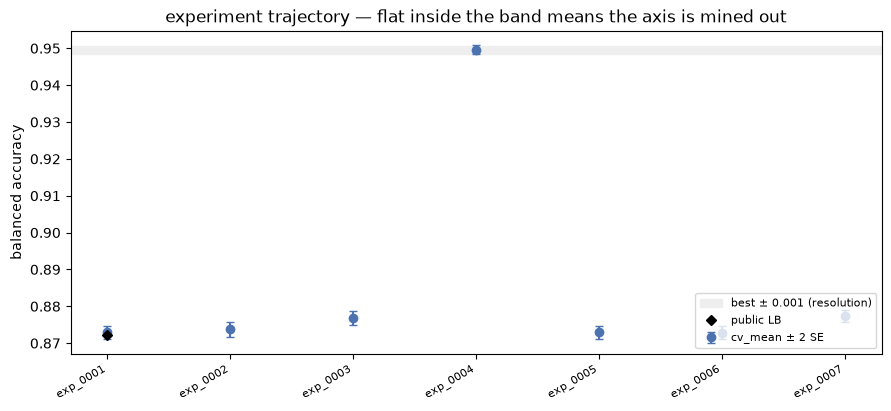

In [6]:
ledger = pl.read_csv(cv.LEDGER)
plots.experiment_compare(ledger.head(7))

Notebook 06 takes the two flat feature experiments and shows where their hypotheses
came from and why the negatives are still worth their runtime; notebook 07 handles
prior correction, ensembling, the decision rule, and when to stop.